In [ ]:
!pip install yfinance quantstats pandas numpy matplotlib seaborn scipy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 1.3 MB/s eta 0:00:00


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import quantstats as qs
from scipy import stats
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

START_DATE       = "2015-01-01"
END_DATE         = datetime.today().strftime("%Y-%m-%d")
TRANSACTION_COST = 0.0010
RBA_CASH_RATE    = 0.0435
RISK_FREE_DAILY  = RBA_CASH_RATE / 252

print("=" * 60)
print("  ASX MOMENTUM FACTOR SCANNER & BACKTESTER")
print("=" * 60)
print(f"  Backtest Period : {START_DATE} to {END_DATE}")
print(f"  Transaction Cost: {TRANSACTION_COST*10000:.0f} bps per leg")
print(f"  RBA Cash Rate   : {RBA_CASH_RATE*100:.2f}%")
print("=" * 60)

  ASX MOMENTUM FACTOR SCANNER & BACKTESTER
  Backtest Period : 2015-01-01 to 2026-06-24
  Transaction Cost: 10 bps per leg
  RBA Cash Rate   : 4.35%


In [ ]:
ASX_TICKERS = [
    "CBA.AX", "NAB.AX", "WBC.AX", "ANZ.AX", "MQG.AX",
    "SUN.AX", "IAG.AX", "QBE.AX",
    "BHP.AX", "RIO.AX", "FMG.AX", "S32.AX", "NCM.AX",
    "OZL.AX", "MIN.AX", "AWC.AX",
    "WDS.AX", "STO.AX", "BPT.AX",
    "WOW.AX", "COL.AX", "TWE.AX", "A2M.AX",
    "WES.AX", "JBH.AX", "HVN.AX", "SUL.AX", "PMV.AX",
    "CSL.AX", "RMD.AX", "COH.AX", "SHL.AX", "RHC.AX",
    "TCL.AX", "SYD.AX", "QAN.AX", "AZJ.AX", "ALX.AX",
    "XRO.AX", "WTC.AX", "CPU.AX", "TYR.AX",
    "GMG.AX", "SCG.AX", "GPT.AX", "DXS.AX",
    "AGL.AX", "APA.AX", "AST.AX",
    "STW.AX"
]

BENCHMARK_TICKER = "STW.AX"
STOCK_TICKERS    = [t for t in ASX_TICKERS if t != BENCHMARK_TICKER]

print(f"Universe size : {len(STOCK_TICKERS)} stocks")
print(f"Benchmark     : {BENCHMARK_TICKER} (ASX 200 ETF)")

Universe size : 49 stocks
Benchmark     : STW.AX (ASX 200 ETF)


In [ ]:
print("\nDownloading price data from Yahoo Finance...")
print("This may take 1-2 minutes...\n")

raw_data = yf.download(
    ASX_TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

prices = raw_data['Close'].copy()

min_observations = int(len(prices) * 0.60)
prices = prices.dropna(axis=1, thresh=min_observations)

benchmark_prices = prices[BENCHMARK_TICKER].copy()
stock_prices     = prices.drop(columns=[BENCHMARK_TICKER], errors='ignore')

stock_prices = stock_prices.fillna(method='ffill', limit=5)

print(f"\nData downloaded successfully!")
print(f"Date range   : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Trading days : {len(prices)}")
print(f"Stocks loaded: {stock_prices.shape[1]}")


This may take 1-2 minutes...



[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
5 Failed downloads:
ERROR:yfinance:['AWC.AX', 'NCM.AX', 'OZL.AX', 'SYD.AX', 'AST.AX']: YFTzMissingError('possibly delisted; no timezone found')



Data downloaded successfully!
Date range   : 2015-01-02 to 2026-06-23
Trading days : 2904
Stocks loaded: 43


In [ ]:
print("\nComputing momentum signals...")

monthly_prices = stock_prices.resample('ME').last()
momentum_raw   = monthly_prices.pct_change(12).shift(1)

benchmark_monthly  = benchmark_prices.resample('ME').last()
benchmark_momentum = benchmark_monthly.pct_change(12).shift(1)

momentum_raw = momentum_raw.dropna(how='all')

print(f"Momentum signals computed!")
print(f"Signal start date: {momentum_raw.dropna(how='all').index[0].date()}")
print(f"\nTop momentum stocks today:")
print((momentum_raw.iloc[-1].dropna().sort_values(ascending=False).head(10) * 100).round(1))


Computing momentum signals...
Momentum signals computed!
Signal start date: 2016-02-29

Top momentum stocks today:
Ticker
MIN.AX    231.1
RIO.AX     71.8
BHP.AX     69.7
S32.AX     62.1
FMG.AX     54.1
AZJ.AX     49.4
WDS.AX     46.1
APA.AX     29.9
ANZ.AX     26.7
STO.AX     24.2
Name: 2026-06-30 00:00:00, dtype: float64


In [ ]:
print("\nForming quintile portfolios...")

monthly_returns   = monthly_prices.pct_change()
portfolio_returns = {1: {}, 2: {}, 3: {}, 4: {}, 5: {}}
rebalance_dates   = momentum_raw.dropna(how='all').index

for i, date in enumerate(rebalance_dates):
    signal = momentum_raw.loc[date].dropna()
    if len(signal) < 10:
        continue
    if i + 1 >= len(rebalance_dates):
        break
    next_date = rebalance_dates[i + 1]

    try:
        signal_ranked = pd.qcut(signal.rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
    except Exception:
        continue

    for q in range(1, 6):
        stocks_in_quintile = signal_ranked[signal_ranked == q].index.tolist()
        try:
            next_returns = monthly_returns.loc[next_date, stocks_in_quintile].dropna()
            if len(next_returns) > 0:
                portfolio_returns[q][next_date] = next_returns.mean()
        except Exception:
            continue

# Build DataFrame - only include quintiles that have data
quintile_dfs = {}
for q in range(1, 6):
    if len(portfolio_returns[q]) > 0:
        quintile_dfs[q] = pd.Series(portfolio_returns[q], name=f'Q{q}')

quintile_returns = pd.DataFrame(quintile_dfs)
quintile_returns.columns = [f'Q{c}' for c in quintile_returns.columns]
quintile_returns.index   = pd.to_datetime(quintile_returns.index)
quintile_returns          = quintile_returns.dropna()

# Verify all 5 quintiles exist
print(f"Quintiles formed: {list(quintile_returns.columns)}")
print(f"Number of monthly rebalances: {len(quintile_returns)}")
print(f"\nAverage monthly return by quintile:")
for col in quintile_returns.columns:
    avg   = quintile_returns[col].mean() * 100
    label = " <- SHORT" if col == 'Q1' else " <- LONG" if col == 'Q5' else ""
    print(f"  {col}: {avg:+.2f}%{label}")


Forming quintile portfolios...
Quintiles formed: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
Number of monthly rebalances: 124

Average monthly return by quintile:
  Q1: +1.16% <- SHORT
  Q2: +1.03%
  Q3: +1.14%
  Q4: +1.18%
  Q5: +1.42% <- LONG


In [ ]:
ls_returns_gross = quintile_returns['Q5'] - quintile_returns['Q1']
monthly_cost     = TRANSACTION_COST * 4
ls_returns_net   = ls_returns_gross - monthly_cost
benchmark_ret    = benchmark_monthly.pct_change().reindex(quintile_returns.index)
q5_net           = quintile_returns['Q5'] - (TRANSACTION_COST * 2)

cum_ls_net    = (1 + ls_returns_net).cumprod()
cum_benchmark = (1 + benchmark_ret.fillna(0)).cumprod()
cum_q5        = (1 + q5_net).cumprod()

ann_ls  = (1 + ls_returns_net.mean()) ** 12 - 1
ann_q5  = (1 + q5_net.mean()) ** 12 - 1
ann_bm  = (1 + benchmark_ret.mean()) ** 12 - 1
vol_ls  = ls_returns_net.std() * np.sqrt(12)
vol_q5  = q5_net.std() * np.sqrt(12)
vol_bm  = benchmark_ret.std() * np.sqrt(12)

rf_monthly = (1 + RBA_CASH_RATE) ** (1/12) - 1
sharpe_ls  = (ls_returns_net.mean() - rf_monthly) / ls_returns_net.std() * np.sqrt(12)
sharpe_q5  = (q5_net.mean() - rf_monthly) / q5_net.std() * np.sqrt(12)
sharpe_bm  = (benchmark_ret.mean() - rf_monthly) / benchmark_ret.std() * np.sqrt(12)

def max_drawdown(returns):
    cum      = (1 + returns).cumprod()
    roll_max = cum.cummax()
    return ((cum - roll_max) / roll_max).min()

dd_ls  = max_drawdown(ls_returns_net)
dd_q5  = max_drawdown(q5_net)
hit_ls = (ls_returns_net > 0).mean()
skew   = stats.skew(ls_returns_net.dropna())
kurt   = stats.kurtosis(ls_returns_net.dropna())

print(f"\n{'='*55}")
print(f"  {'Metric':<25} {'L/S':>10} {'Long Q5':>10} {'ASX200':>8}")
print(f"  {'-'*55}")
print(f"  {'Ann. Return':<25} {ann_ls*100:>9.1f}% {ann_q5*100:>9.1f}% {ann_bm*100:>7.1f}%")
print(f"  {'Volatility':<25} {vol_ls*100:>9.1f}% {vol_q5*100:>9.1f}% {vol_bm*100:>7.1f}%")
print(f"  {'Sharpe Ratio':<25} {sharpe_ls:>10.2f} {sharpe_q5:>10.2f} {sharpe_bm:>8.2f}")
print(f"  {'Max Drawdown':<25} {dd_ls*100:>9.1f}% {dd_q5*100:>9.1f}%")
print(f"  {'Monthly Hit Rate':<25} {hit_ls*100:>9.1f}%")
print(f"{'='*55}")


  Metric                           L/S    Long Q5   ASX200
  -------------------------------------------------------
  Ann. Return                    -1.6%      15.7%    11.0%
  Volatility                     18.6%      17.8%    13.1%
  Sharpe Ratio                   -0.31       0.59     0.47
  Max Drawdown                  -44.8%     -24.8%
  Monthly Hit Rate               48.4%


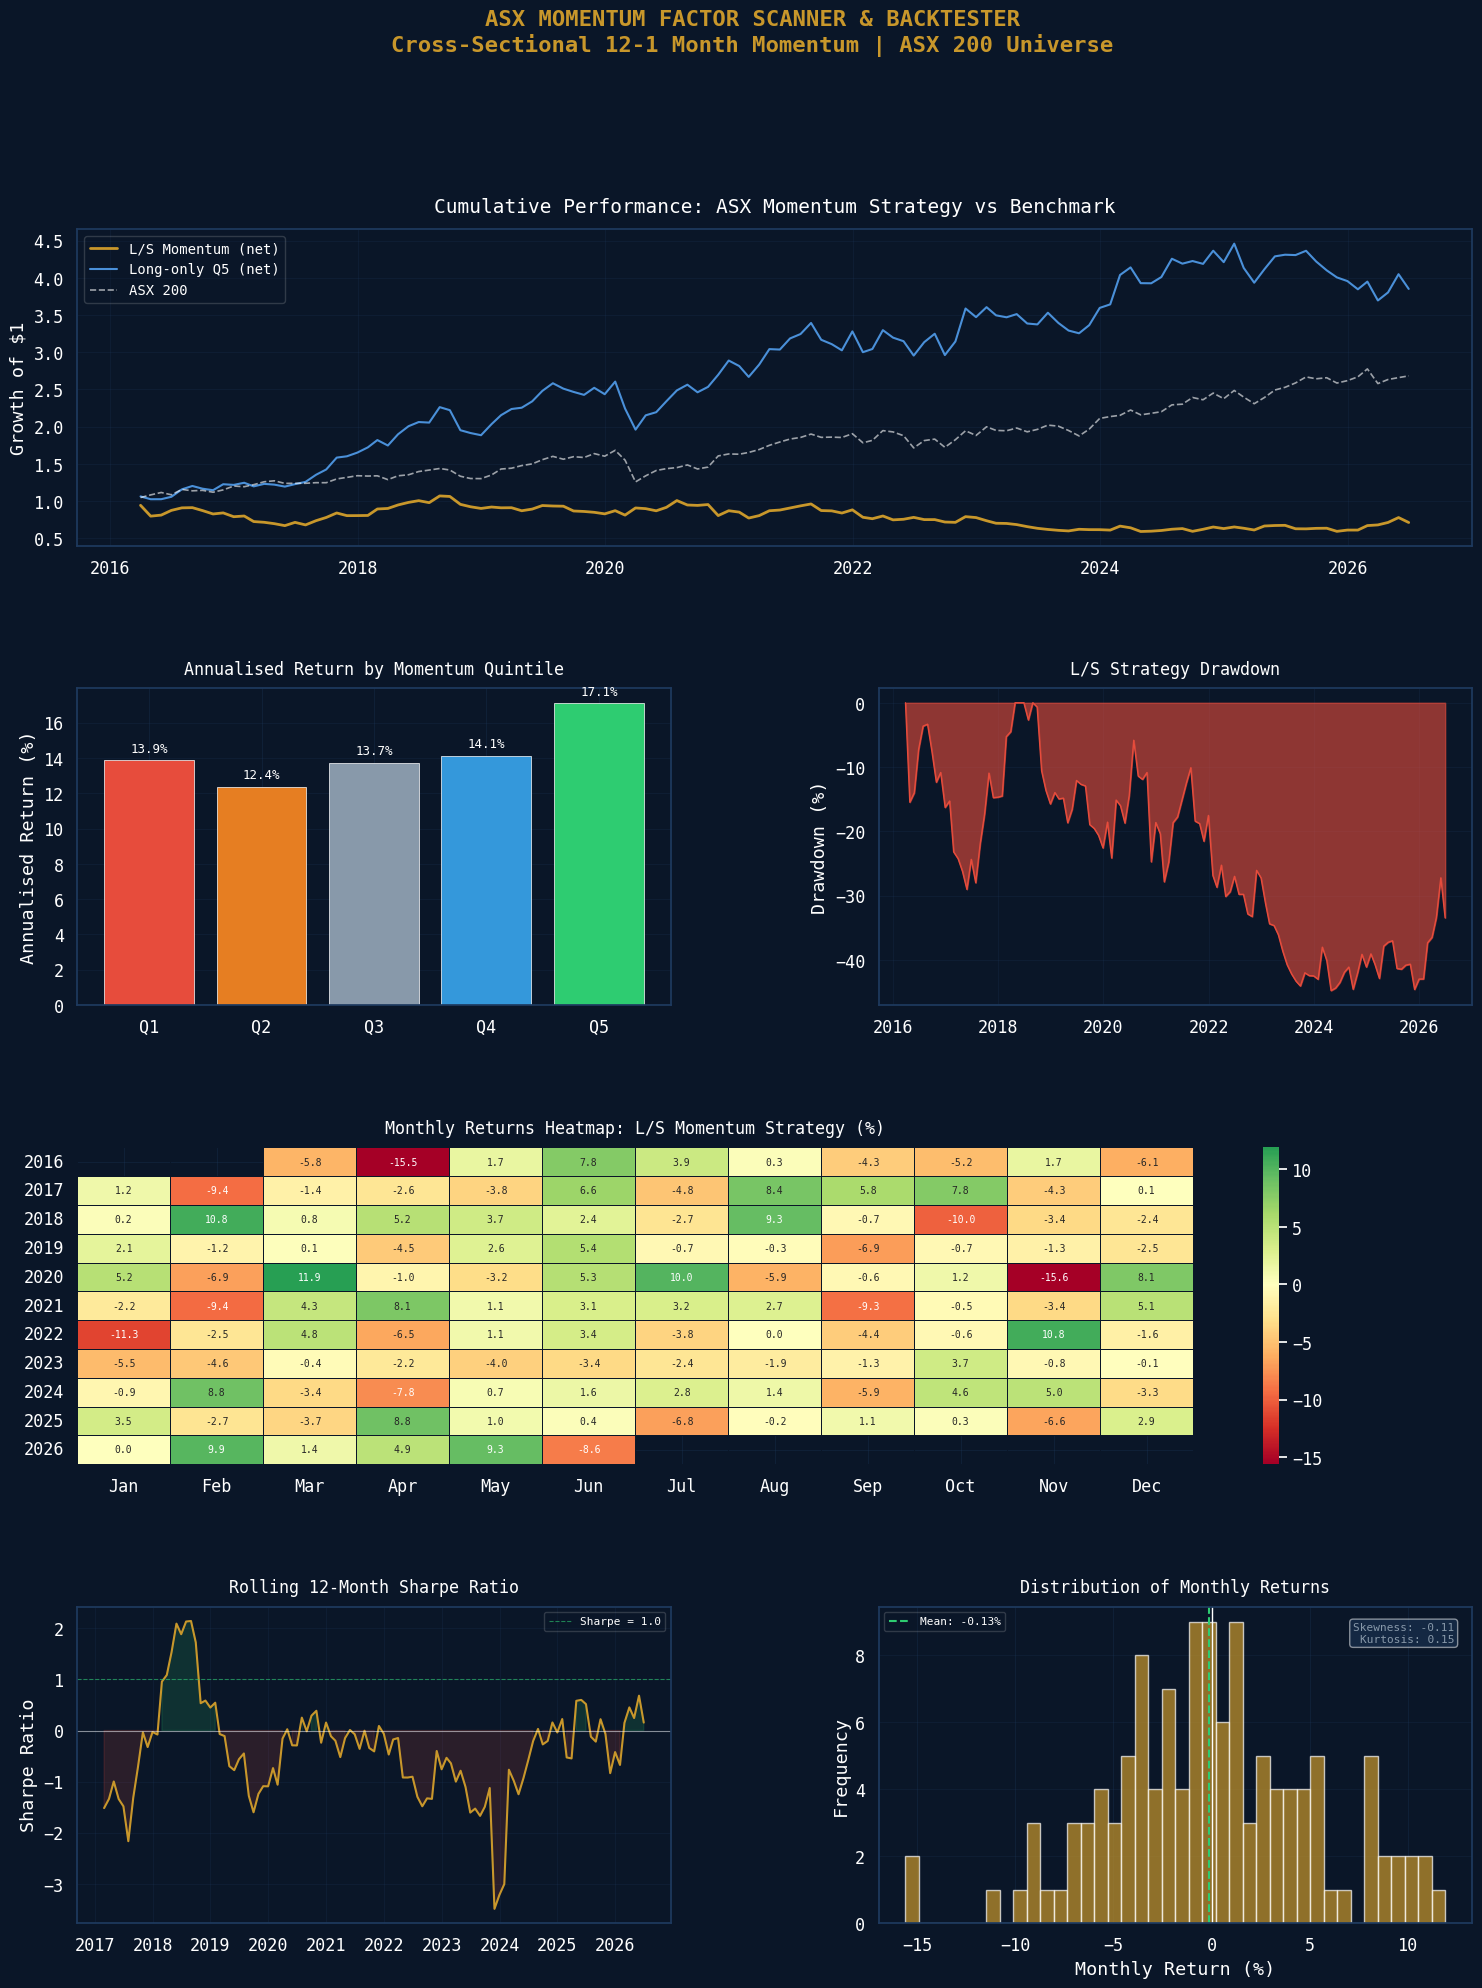

Chart saved!


In [ ]:
fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_ls_net.index, cum_ls_net.values, color=GOLD,  lw=2.0, label='L/S Momentum (net)')
ax1.plot(cum_q5.index,     cum_q5.values,     color=BLUE,  lw=1.5, label='Long-only Q5 (net)')
ax1.plot(cum_benchmark.index, cum_benchmark.values, color=WHITE, lw=1.2, label='ASX 200', alpha=0.6, linestyle='--')
ax1.set_title('Cumulative Performance: ASX Momentum Strategy vs Benchmark', fontsize=14, color=WHITE, pad=12)
ax1.set_ylabel('Growth of $1', color=WHITE)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.2)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#0A1628')

ax2 = fig.add_subplot(gs[1, 0])
quintile_avg    = [quintile_returns[f'Q{q}'].mean() * 100 * 12 for q in range(1, 6)]
quintile_colors = [RED, '#E67E22', GREY, '#3498DB', GREEN]
bars = ax2.bar([f'Q{q}' for q in range(1, 6)], quintile_avg, color=quintile_colors, edgecolor='white', linewidth=0.5)
ax2.axhline(y=0, color='white', lw=0.8, alpha=0.5)
ax2.set_title('Annualised Return by Momentum Quintile', fontsize=12, color=WHITE, pad=10)
ax2.set_ylabel('Annualised Return (%)', color=WHITE)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, quintile_avg):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
drawdown_series = (cum_ls_net / cum_ls_net.cummax() - 1) * 100
ax3.fill_between(drawdown_series.index, drawdown_series.values, 0, color=RED, alpha=0.6)
ax3.plot(drawdown_series.index, drawdown_series.values, color=RED, lw=1.0)
ax3.set_title('L/S Strategy Drawdown', fontsize=12, color=WHITE, pad=10)
ax3.set_ylabel('Drawdown (%)', color=WHITE)
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[2, :])
ls_monthly_df       = ls_returns_net.copy()
ls_monthly_df.index = pd.to_datetime(ls_monthly_df.index)
heatmap_data        = ls_monthly_df.groupby([ls_monthly_df.index.year, ls_monthly_df.index.month]).mean().unstack()
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(heatmap_data * 100, ax=ax4, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', linewidths=0.5, linecolor='#0A1628',
            annot_kws={'size': 7})
ax4.set_title('Monthly Returns Heatmap: L/S Momentum Strategy (%)', fontsize=12, color=WHITE, pad=10)
ax4.set_facecolor('#0A1628')

ax5 = fig.add_subplot(gs[3, 0])
rolling_sharpe = ls_returns_net.rolling(12).apply(
    lambda x: (x.mean() - rf_monthly) / x.std() * np.sqrt(12) if x.std() > 0 else 0
)
ax5.plot(rolling_sharpe.index, rolling_sharpe.values, color=GOLD, lw=1.5)
ax5.axhline(y=0, color='white', lw=0.8, alpha=0.5)
ax5.axhline(y=1, color=GREEN,   lw=0.8, alpha=0.6, linestyle='--', label='Sharpe = 1.0')
ax5.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                 where=rolling_sharpe.values > 0, color=GREEN, alpha=0.15)
ax5.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                 where=rolling_sharpe.values < 0, color=RED, alpha=0.15)
ax5.set_title('Rolling 12-Month Sharpe Ratio', fontsize=12, color=WHITE, pad=10)
ax5.set_ylabel('Sharpe Ratio', color=WHITE)
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=8, framealpha=0.2)

ax6 = fig.add_subplot(gs[3, 1])
ax6.hist(ls_returns_net * 100, bins=40, color=GOLD, alpha=0.7, edgecolor='white', lw=0.4)
ax6.axvline(x=0, color='white', lw=1.0)
ax6.axvline(x=ls_returns_net.mean()*100, color=GREEN, lw=1.5, linestyle='--',
            label=f'Mean: {ls_returns_net.mean()*100:.2f}%')
ax6.set_title('Distribution of Monthly Returns', fontsize=12, color=WHITE, pad=10)
ax6.set_xlabel('Monthly Return (%)', color=WHITE)
ax6.set_ylabel('Frequency', color=WHITE)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3, axis='y')
ax6.legend(fontsize=8, framealpha=0.2)
ax6.text(0.97, 0.95, f'Skewness: {skew:.2f}\nKurtosis: {kurt:.2f}',
         transform=ax6.transAxes, fontsize=8, color=GREY, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='#1E3A5F', alpha=0.5))

fig.suptitle('ASX MOMENTUM FACTOR SCANNER & BACKTESTER\nCross-Sectional 12-1 Month Momentum | ASX 200 Universe',
             fontsize=16, color=GOLD, y=0.98, fontweight='bold')

plt.savefig('asx_momentum_backtest.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
plt.show()
print("Chart saved!")

In [ ]:
print("\n" + "=" * 60)
print("  CURRENT MOMENTUM RANKINGS (as of today)")
print("=" * 60)

latest_signal = momentum_raw.iloc[-1].dropna().sort_values(ascending=False)

print(f"\nDate: {momentum_raw.index[-1].date()}")
print(f"\nTOP 10 - HIGHEST MOMENTUM (Long Candidates):")
print(f"{'Rank':<6} {'Ticker':<12} {'12-1M Return':>15}")
print("-" * 35)
for rank, (ticker, ret) in enumerate(latest_signal.head(10).items(), 1):
    print(f"  {rank:<4} {ticker:<12} {ret*100:>+13.1f}%")

print(f"\nBOTTOM 10 - LOWEST MOMENTUM (Short Candidates):")
print(f"{'Rank':<6} {'Ticker':<12} {'12-1M Return':>15}")
print("-" * 35)
for rank, (ticker, ret) in enumerate(latest_signal.tail(10).iloc[::-1].items(), 1):
    print(f"  {rank:<4} {ticker:<12} {ret*100:>+13.1f}%")


  CURRENT MOMENTUM RANKINGS (as of today)

Date: 2026-06-30

TOP 10 - HIGHEST MOMENTUM (Long Candidates):
Rank   Ticker          12-1M Return
-----------------------------------
  1    MIN.AX              +231.1%
  2    RIO.AX               +71.8%
  3    BHP.AX               +69.7%
  4    S32.AX               +62.1%
  5    FMG.AX               +54.1%
  6    AZJ.AX               +49.4%
  7    WDS.AX               +46.1%
  8    APA.AX               +29.9%
  9    ANZ.AX               +26.7%
  10   STO.AX               +24.2%

BOTTOM 10 - LOWEST MOMENTUM (Short Candidates):
Rank   Ticker          12-1M Return
-----------------------------------
  1    WTC.AX               -66.3%
  2    COH.AX               -62.2%
  3    CSL.AX               -59.9%
  4    XRO.AX               -59.2%
  5    TWE.AX               -48.5%
  6    PMV.AX               -36.7%
  7    A2M.AX               -34.3%
  8    JBH.AX               -27.9%
  9    RMD.AX               -23.7%
  10   SHL.AX               -23.4%


In [ ]:
print("\n" + "=" * 60)
print("  QUANTSTATS PERFORMANCE REPORT")
print("=" * 60)

metrics = {
    "Total Return"     : f"{(cum_ls_net.iloc[-1] - 1) * 100:.1f}%",
    "CAGR"             : f"{ann_ls * 100:.1f}%",
    "Sharpe Ratio"     : f"{sharpe_ls:.2f}",
    "Max Drawdown"     : f"{dd_ls * 100:.1f}%",
    "Calmar Ratio"     : f"{ann_ls / abs(dd_ls):.2f}",
    "Monthly Win Rate" : f"{hit_ls * 100:.1f}%",
    "Best Month"       : f"{ls_returns_net.max() * 100:.1f}%",
    "Worst Month"      : f"{ls_returns_net.min() * 100:.1f}%",
    "Ann. Volatility"  : f"{vol_ls * 100:.1f}%",
    "Skewness"         : f"{skew:.2f}",
    "Kurtosis"         : f"{kurt:.2f}",
}
for metric, value in metrics.items():
    print(f"  {metric:<25} {value:>10}")

print("=" * 60)
print("\n  PROJECT 1 COMPLETE!")
print("  - Charts displayed above")
print("  - asx_momentum_backtest.png saved")
print("  - Ready to upload to GitHub!")
print("=" * 60)


  QUANTSTATS PERFORMANCE REPORT
  Total Return                  -28.9%
  CAGR                           -1.6%
  Sharpe Ratio                   -0.31
  Max Drawdown                  -44.8%
  Calmar Ratio                   -0.03
  Monthly Win Rate               48.4%
  Best Month                     11.9%
  Worst Month                   -15.6%
  Ann. Volatility                18.6%
  Skewness                       -0.11
  Kurtosis                        0.15

  PROJECT 1 COMPLETE!
  - Charts displayed above
  - asx_momentum_backtest.png saved
  - Ready to upload to GitHub!


In [3]:
from google.colab import files

plt.savefig('asx_momentum_backtest.png', dpi=150, bbox_inches='tight', facecolor='#0A1628')
files.download('asx_momentum_backtest.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>